In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import scipy.io as sio

In [ ]:
from sessions import *
from pyNeuroDAP.spikes import *
from pyNeuroDAP.plots import *

Each neuron: laser_mod_index <--> left_right_tone_index, left_right_lick_index, reward_index

- tone: 25 ms
- reward is delivered as soon as the first selection lick is detected
- ENL: 1500 + np.ranodom(0,500)

## 1. Load the data from folder

In [23]:
# import tkinter as tk
# from tkinter import filedialog
# # Hide the main tkinter window
# root = tk.Tk()
# root.withdraw()

# # Open a dialog to select the session folder
# base_folder = filedialog.askdirectory(title="Select session folder", initialdir=r"/Users/shunli/Downloads/sabalab/forPaolo")
# # Extract the session_id from the selected folder name
# session_id = os.path.basename(base_folder)
# print(f"Selected session_id: {session_id}")
# print(f"Base folder: {base_folder}")

In [24]:
# Hard loading

# base_folder = rf"/Users/shunli/Downloads/sabalab/forPaolo/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"

# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001"
# base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250323_5mW_500ms_500delay_032325001"
base_folder = rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250328_Licking_032825001"

# Extract the session_id from the last part of the path
session_id = os.path.basename(base_folder)
print(f"Selected session_id: {session_id}")

Selected session_id: Rec_Upstream_DCN_1_250328_Licking_032825001


In [25]:
laser_onset_1 = 0.0
laser_duration = 0.5 # 500ms
output_folder_psth_1 = "laser_psth_20bin_100reward_500delay"

# if split trial, above variables used for first block
split_trial = False
#split_trial = True
block_1_end = 171 # end of block 1
block_2_start = 190
block_2_end = 390 # end of block 2
laser_onset_2 = 0.0 # 500ms
output_folder_psth_2 = "laser_psth_20bin_500reward_0delay"

# output folder
output_folder_psth_1_path = rf"{base_folder}/results/{output_folder_psth_1}"
output_folder_psth_2_path = rf"{base_folder}/results/{output_folder_psth_2}"
os.makedirs(output_folder_psth_1_path, exist_ok=True)
os.makedirs(output_folder_psth_2_path, exist_ok=True)

####################### DO NOT CHANGE BELOW ########################
ap_fs = 40000
# Load spike data and laser timestamps
spikes_path = rf"{base_folder}/spikeinterface/analyzer/sorting/spikes.npy"
laser_times_path = rf"{base_folder}/{session_id}.mat"
reward_trials_path = rf"{base_folder}/{session_id}_analysis.mat"
laser_type = "laser_on_evt05"

spikes_raw = np.load(spikes_path, allow_pickle=True)
spikes = np.stack([spikes_raw['sample_index'], spikes_raw['unit_index'], spikes_raw['segment_index']], axis=1)
mat_data = sio.loadmat(laser_times_path)

In [26]:
# Load trial data from csv
csv_path_csv = rf"{base_folder}/trial_data.csv"
all_trial_data_df = pd.read_csv(csv_path_csv)

# Modify trial dataframe so that licks exists in vectors
import re

def extract_lick_columns(df, side):
    # side: "Right" or "Left"
    pattern = re.compile(rf"{side}LickingTimestamps_(\d+)")
    lick_cols = []
    for col in df.columns:
        m = pattern.fullmatch(col)
        if m:
            lick_cols.append((int(m.group(1)), col))
    # Sort by lick number
    lick_cols.sort()
    return [col for _, col in lick_cols]

# Get all right and left lick columns
right_lick_cols = extract_lick_columns(all_trial_data_df, "Right")
left_lick_cols = extract_lick_columns(all_trial_data_df, "Left")

lick_times_list = []
lick_sides_list = []

for idx, row in all_trial_data_df.iterrows():
    lick_times = []
    lick_sides = []
    # Right licks
    for col in right_lick_cols:
        val = row[col]
        if pd.notnull(val):
            lick_times.append(val)
            lick_sides.append(1)
    # Left licks
    for col in left_lick_cols:
        val = row[col]
        if pd.notnull(val):
            lick_times.append(val)
            lick_sides.append(0)
    # Sort by time
    if lick_times:
        sorted_indices = np.argsort(lick_times)
        lick_times_sorted = [lick_times[i] for i in sorted_indices]
        lick_sides_sorted = [lick_sides[i] for i in sorted_indices]
    else:
        lick_times_sorted = []
        lick_sides_sorted = []
    lick_times_list.append(lick_times_sorted)
    lick_sides_list.append(lick_sides_sorted)

all_trial_data_df["lick_times"] = lick_times_list
all_trial_data_df["lick_sides"] = lick_sides_list

# Remove all columns containing "LickingTimestamps" from the DataFrame
licking_timestamp_cols = [col for col in all_trial_data_df.columns if "LickingTimestamps" in col]
all_trial_data_df = all_trial_data_df.drop(columns=licking_timestamp_cols)

# Separate into blocks if necessary
trials_block1_df = all_trial_data_df.iloc[:block_1_end].copy()
trials_block2_df = all_trial_data_df.iloc[block_2_start:block_2_end].copy()


In [ ]:
all_trial_data_df.head()

,TrialNumber,TrialSide,IsLaserTrial,LaserDelay,RMI,TimeStart,TimeEnd,TimeDelta,CorrectLickPercentage,CorrectLickBefore,CorrectLickAfter,FirstLickLatency,FirstLickLaserLatency,FirstLickPostLaser,NumLicks,LickDuration,lick_times,lick_sides
0,2,Right,1,0.000025,mistrial,5.051750,62.919850,57.868100,0.000000,0.0,0.0,NaN,NaN,NaN,0,NaN,[],[]
1,3,Right,0,NaN,mistrial,62.919850,71.845775,8.925925,0.000000,0.0,0.0,NaN,NaN,NaN,0,NaN,[],[]
2,4,Left,0,NaN,reward,71.845775,79.853150,8.007375,75.000000,NaN,NaN,0.357475,NaN,NaN,12,1.525875,"[72.20325, 72.368025, 72.535375, 72.68025, 72....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1]"
3,5,Right,0,NaN,mistrial,79.853150,90.350600,10.497450,33.333333,NaN,NaN,1.319875,NaN,NaN,3,0.332550,"[81.173025, 81.317725, 81.505575]","[0, 0, 1]"
4,6,Right,0,NaN,incorrect,90.350600,95.587975,5.237375,69.230769,NaN,NaN,0.449500,NaN,NaN,13,1.412300,"[90.8001, 90.957425, 91.13855, 91.138575, 91.2...","[0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1]"


## 2. Extract behavior event times (lasers, lick, tone, etc)

In [28]:
# Trial conditions
trial_conditions = [
    'reward_right_laser', 'reward_left_laser', 'nonreward_right_laser', 'nonreward_left_laser',
    'reward_right_control', 'reward_left_control', 'nonreward_right_control', 'nonreward_left_control'
]

# Initialize dicts for trial start, choice lick, second lick, and last lick times for each trial condition
trial_start_times   = {cond: [] for cond in trial_conditions}
choice_lick_times   = {cond: [] for cond in trial_conditions}
second_lick_times   = {cond: [] for cond in trial_conditions}
last_lick_times     = {cond: [] for cond in trial_conditions}

# ------------- select trials -----------------------
trial_data_df = all_trial_data_df

for _, trial in trial_data_df.iterrows(): 

    try:
        trial_number = trial['TrialNumber']
        trial_time = trial['TimeStart']
        is_laser = trial['IsLaserTrial'] == 1
        is_right = trial['TrialSide'] == 'Right'
        is_rewarded = trial['RMI'] == 'reward'


        # Determine trial condition string
        if is_laser:
            if is_right:
                cond = 'reward_right_laser' if is_rewarded else 'nonreward_right_laser'
            else:
                cond = 'reward_left_laser' if is_rewarded else 'nonreward_left_laser'
        else:
            if is_right:
                cond = 'reward_right_control' if is_rewarded else 'nonreward_right_control'
            else:
                cond = 'reward_left_control' if is_rewarded else 'nonreward_left_control'
        # Store trial start time in the correct list
        trial_start_times[cond].append(trial_time)


        # Lick timings
        # Extract lick times from the trial
        lick_times = trial.get('lick_times', None)
        # lick_sides = trial.get('lick_sides', None)
        if lick_times is None or not isinstance(lick_times, (list, np.ndarray)) or len(lick_times) == 0:
            first_lick = np.nan
            second_lick = np.nan
            last_lick = np.nan
        else:
            first_lick = lick_times[0] if len(lick_times) > 0 else np.nan
            second_lick = lick_times[1] if len(lick_times) > 1 else np.nan
            last_lick = lick_times[-1] if len(lick_times) > 0 else np.nan
        # Store lick times in the correct lists
        choice_lick_times[cond].append(first_lick)
        second_lick_times[cond].append(second_lick)
        last_lick_times[cond].append(last_lick)


    except Exception as e:
        print(f"Error processing trial: {e}")
        continue

# convert lists to numpy arrays for downstream compatibility
for cond in trial_conditions:
    trial_start_times[cond] = np.array(trial_start_times[cond])
    choice_lick_times[cond] = np.array(choice_lick_times[cond])
    second_lick_times[cond] = np.array(second_lick_times[cond])
    last_lick_times[cond] = np.array(last_lick_times[cond])

In [ ]:
# Save trial table and event times to hdf5 file

# Prepare trial table for saving (convert to dict if it's a DataFrame)
trials = all_trial_data_df
if hasattr(trials, 'to_dict'):
    trial_table_to_save = trials.to_dict('list')
else:
    trial_table_to_save = trials

# Add event times and trial_conditions directly to the trial_table dict
# Convert event times and trial_conditions to dicts of lists (for HDF5 compatibility)
event_times_to_save = {}
for name, arr in [
    ('trial_start_times', trial_start_times),
    ('choice_lick_times', choice_lick_times),
    ('second_lick_times', second_lick_times),
    ('last_lick_times', last_lick_times)
]:
    # Each is a dict of arrays; convert to dict of lists for saving
    event_times_to_save[name] = {cond: arr[cond].tolist() for cond in arr}

# Save trial_conditions as a list (if not already)
trial_conditions_to_save = list(trial_conditions) if not isinstance(trial_conditions, list) else trial_conditions

# Insert event_times and trial_conditions into the trial_table dict
trial_table_to_save['event_times'] = event_times_to_save
trial_table_to_save['trial_conditions'] = trial_conditions_to_save

# Save session data (trial table only for now, aligned spikes will be added later)
session_file = save_session_data(
    session_name='session_2024_01_15',
    trial_table=trial_table_to_save,
    aligned_spikes={},  # No spikes yet, will add later
    metadata={
        'experiment_type': 'opto_psth',
        'subject_id': 'mouse_001',
        'recording_location': 'DCN'
    }
)

print(f"Session file created: {session_file}")

## 3. Align spikes to different behavior events

### 3.1 Get spikes

In [30]:
bin_size = 25           # in ms
time_range = (-1,2)     # in sec
nbins = int(np.round((time_range[1] - time_range[0]) / (bin_size/1000)))
xaxis = np.linspace(time_range[0],time_range[1],nbins)

print('Aligning spikes to behavior events...')

# Align spikes to all trial start times for each condition in trial_start_times
aligned_trial_start = {}
for cond, event_times in trial_start_times.items():
    aligned_trial_start[cond] = get_spikes(spikes, np.array(event_times), time_range, bin_size_ms=bin_size)
print('Finished: get spikes for trial starts')

aligned_choice_lick = {}
for cond, event_times in choice_lick_times.items():
    aligned_choice_lick[cond] = get_spikes(spikes, np.array(event_times), time_range, bin_size_ms=bin_size)
print('Finished: get spikes for choice lick')

aligned_second_lick = {}
for cond, event_times in second_lick_times.items():
    aligned_second_lick[cond] = get_spikes(spikes, np.array(event_times), time_range, bin_size_ms=bin_size)
print('Finished: get spikes for second lick')

aligned_last_lick = {}
for cond, event_times in last_lick_times.items():
    aligned_last_lick[cond] = get_spikes(spikes, np.array(event_times), time_range, bin_size_ms=bin_size)
print('Finished: get spikes for last lick')

Aligning spikes to behavior events...
Finished: get spikes for trial starts
Finished: get spikes for choice lick
Finished: get spikes for second lick
Finished: get spikes for last lick


In [ ]:
# Save aligned spikes to hdf5 file

# Collect all aligned spikes into a single dictionary
all_aligned_spikes = {
    'trial_start': aligned_trial_start,
    'choice_lick': aligned_choice_lick,
    'second_lick': aligned_second_lick,
    'last_lick': aligned_last_lick
}

# Save to the session file created above
add_to_session(session_file, all_aligned_spikes, data_type='aligned_spikes')


### 3.2. Get modulation index

- Tone
- Choice lick (left vs right encoding)
- reward
- laser

In [31]:
mod_index_type = 'norm'

# ----------------------------- Tone -----------------------------
response_window = (0, 50)   # start at 10 ms, end at 200 ms

# combined event and control data
tone_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
tone_rates = np.concatenate([aligned_trial_start[k]['rate'] for k in tone_keys], axis=1)

control_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
ctrl_rates = np.concatenate([aligned_trial_start[k]['rate'] for k in control_keys], axis=1)

# get tone mod index
tone_rates = get_window(tone_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
ctrl_rates = get_window(ctrl_rates, onset_time=0, window_ms=(-75,-25), time_range=time_range, bin_size_ms=bin_size)
tone_mod_index = get_mod_index(tone_rates, ctrl_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(tone_mod_index)[-5:][::-1]
idx_supp    = np.argsort(tone_mod_index)[:5]
print("Top 5 excited neurons by tone:", idx_excited, tone_mod_index[idx_excited])
print("Top 5 suppressed neurons by tone:", idx_supp, tone_mod_index[idx_supp])


# ----------------------------- Choice (left vs right encoding) -----------------------------
response_window = (0, 75)   # start at 10 ms, end at 200 ms

# combined event and control data
left_keys = ['reward_left_control', 'nonreward_left_control']
left_rates = np.concatenate([aligned_choice_lick[k]['rate'] for k in left_keys], axis=1)

right_keys = ['reward_right_control', 'nonreward_right_control']
right_rates = np.concatenate([aligned_choice_lick[k]['rate'] for k in right_keys], axis=1)

# get mod index
left_rates = get_window(left_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
right_rates = get_window(right_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
choice_mod_index = get_mod_index(left_rates, right_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(choice_mod_index)[-5:][::-1]
idx_supp    = np.argsort(choice_mod_index)[:5]
print("Top 5 excited neurons by choice:", idx_excited, choice_mod_index[idx_excited])
print("Top 5 suppressed neurons by choice", idx_supp, choice_mod_index[idx_supp])


# ----------------------------- Motor -----------------------------
response_window = (0, 100)   # start at 10 ms, end at 200 ms
control_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
ctrl_rates = np.concatenate([aligned_last_lick[k]['rate'] for k in control_keys], axis=1)

# get mod index
lick_rates = get_window(ctrl_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
ctrl_rates = get_window(ctrl_rates, onset_time=0, window_ms=(150,250), time_range=time_range, bin_size_ms=bin_size)
motor_mod_index = get_mod_index(lick_rates, ctrl_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(motor_mod_index)[-5:][::-1]
idx_supp    = np.argsort(motor_mod_index)[:5]
print("Top 5 excited neurons by motor:", idx_excited, motor_mod_index[idx_excited])
print("Top 5 suppressed neurons by motor:", idx_supp, motor_mod_index[idx_supp])


# ----------------------------- Reward -----------------------------
response_window = (0, 200)   # start at 10 ms, end at 200 ms

# combined event and control data
reward_keys = ['reward_left_control', 'reward_right_control']
reward_rates = np.concatenate([aligned_second_lick[k]['rate'] for k in reward_keys], axis=1)

nonreward_keys = ['nonreward_left_control', 'nonreward_right_control']
nonreward_rates = np.concatenate([aligned_second_lick[k]['rate'] for k in nonreward_keys], axis=1)

# get mod index
reward_rates = get_window(reward_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
nonreward_rates = get_window(nonreward_rates, onset_time=0, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
reward_mod_index = get_mod_index(reward_rates, nonreward_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(reward_mod_index)[-5:][::-1]
idx_supp    = np.argsort(reward_mod_index)[:5]
print("Top 5 excited neurons by reward:", idx_excited, reward_mod_index[idx_excited])
print("Top 5 suppressed neurons by reward:", idx_supp, reward_mod_index[idx_supp])


# ----------------------------- Laser -----------------------------
laser_onset = 1.0                   # in sec
response_window = (10, 200)   # start at 10 ms, end at 200 ms

# combined event and control data
laser_keys = ['reward_left_laser', 'nonreward_left_laser', 'reward_right_laser', 'nonreward_right_laser']
laser_rates = np.concatenate([aligned_trial_start[k]['rate'] for k in laser_keys], axis=1)

control_keys = ['reward_left_control', 'nonreward_left_control', 'reward_right_control', 'nonreward_right_control']
control_rates = np.concatenate([aligned_trial_start[k]['rate'] for k in control_keys], axis=1)

# get laser mod index
laser_rates = get_window(laser_rates, onset_time=laser_onset, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
control_rates = get_window(control_rates, onset_time=laser_onset, window_ms=response_window, time_range=time_range, bin_size_ms=bin_size)
laser_mod_index = get_mod_index(laser_rates, control_rates, type=mod_index_type)

# Example: print top 5 most excited and suppressed neurons
idx_excited = np.argsort(laser_mod_index)[-5:][::-1]
idx_supp    = np.argsort(laser_mod_index)[:5]
print("Top 5 excited neurons by laser:", idx_excited, laser_mod_index[idx_excited])
print("Top 5 suppressed neurons by laser:", idx_supp, laser_mod_index[idx_supp])

Top 5 excited neurons by tone: [181   9 201 217  46] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by tone: [120 308  59  58 260] [-1. -1. -1. -1. -1.]
Top 5 excited neurons by choice: [126 341 259 172  79] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by choice [193 263 231 275  53] [-1. -1. -1. -1. -1.]
Top 5 excited neurons by motor: [ 81 279 194  42   5] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by motor: [339  45  89 334 114] [-1. -1. -1. -1. -1.]
Top 5 excited neurons by reward: [275 126  56 202 125] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by reward: [290 257   4 241 199] [-1. -1. -1. -1. -1.]
Top 5 excited neurons by laser: [111 112 135 121  84] [1. 1. 1. 1. 1.]
Top 5 suppressed neurons by laser: [260  45 231 189 194] [-1. -1. -1. -1. -1.]


### 3.3. Plot modulation index

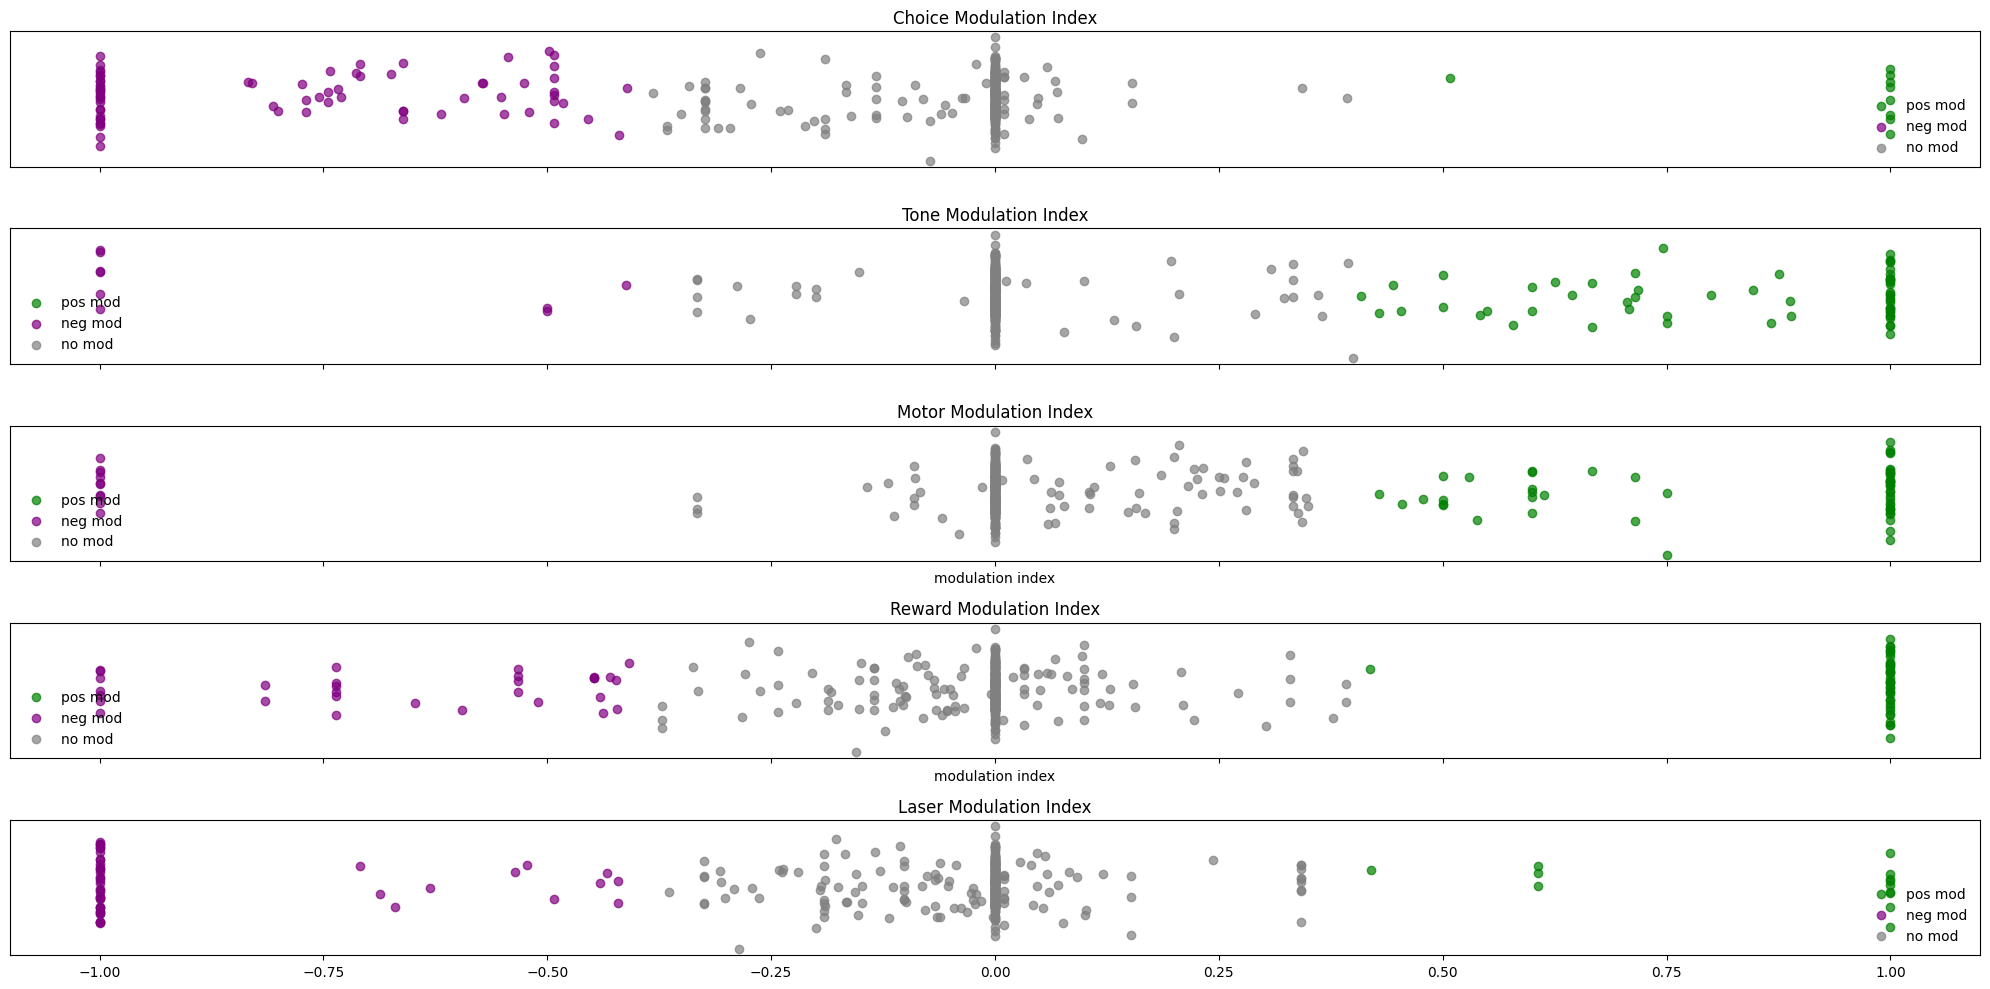

In [32]:
# Plot and group all modulation indices in a 2x2 grid of subplots
mod_indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index),
    ("Laser Modulation Index", laser_mod_index)
]

fig, axes = plt.subplots(len(mod_indices), 1, figsize=(20, 10), sharex=True)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

# Use the same y_jitter for all plots, based on the number of units (assume all mod indices have same length)
y_jitter = np.random.normal(loc=0, scale=0.1, size=laser_mod_index.size)

pos_mod_color = 'green'
neg_mod_color = 'purple'
no_mod_color = 'gray'
th = 0.4

for ax, (title, mod_index) in zip(axes_flat, mod_indices):
    pos_mask = mod_index > th
    neg_mask = mod_index < -th
    no_mask  = (~pos_mask & ~neg_mask)
    ax.scatter(mod_index[pos_mask], y_jitter[pos_mask],
               color=pos_mod_color, alpha=0.7, label='pos mod')
    ax.scatter(mod_index[neg_mask], y_jitter[neg_mask],
               color=neg_mod_color, alpha=0.7, label='neg mod')
    ax.scatter(mod_index[no_mask],  y_jitter[no_mask],
               color=no_mod_color,  alpha=0.7, label='no mod')
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_title(title)
    ax.legend(frameon=False)

# Set xlabel only for bottom row
for i, ax in enumerate(axes_flat):
    if i // 2 == 1:  # bottom row
        ax.set_xlabel('modulation index')

plt.tight_layout()

/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_99910/642381697.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


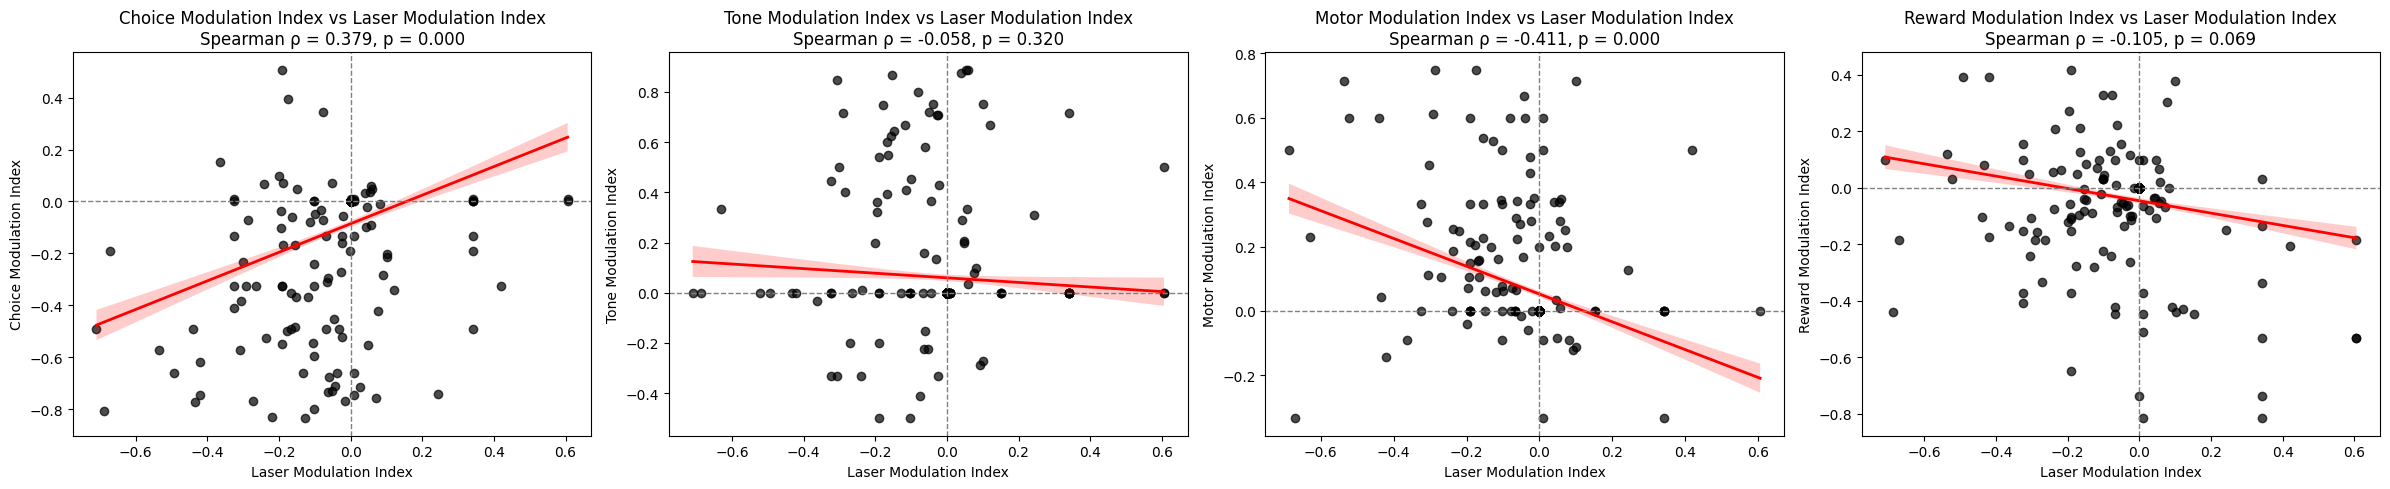

: 

In [ ]:
# Three scatter plots: laser_mod_index (x) vs other indices (y), 1 row x 3 columns, with best fit line and Spearman correlation
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index)
]

for ax, (title, y_index) in zip(axes, indices):
    # Remove indices of 1 and -1
    tol = 1e-8
    mask = ~(
        np.isclose(np.abs(laser_mod_index), 1.0, atol=tol) |
        np.isclose(np.abs(y_index), 1.0, atol=tol)
    )
    laser_mod_index_clean = laser_mod_index[mask]
    y_index_clean = y_index[mask]

    # Scatter plot
    ax.scatter(laser_mod_index_clean, y_index_clean, color='black', alpha=0.7)
    # Best fit line (linear regression)
    m, b = np.polyfit(laser_mod_index_clean, y_index_clean, 1)
    x_fit = np.linspace(np.min(laser_mod_index_clean), np.max(laser_mod_index_clean), 100)
    y_fit = m * x_fit + b

    # Calculate SEM of the fit line
    # For each x_fit, compute predicted y, then SEM of residuals
    y_pred = m * laser_mod_index_clean + b
    residuals = y_index_clean - y_pred
    # Standard error of the regression (residuals)
    n = len(laser_mod_index_clean)
    if n > 2:
        s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    else:
        s_err = np.nan

    # For each x_fit, calculate SEM of the fit line
    x_mean = np.mean(laser_mod_index_clean)
    Sxx = np.sum((laser_mod_index_clean - x_mean) ** 2)
    if Sxx > 0 and n > 2:
        sem_fit = s_err * np.sqrt(1/n + (x_fit - x_mean)**2 / Sxx)
    else:
        sem_fit = np.full_like(x_fit, np.nan)

    ax.plot(x_fit, y_fit, color='red', linestyle='-', linewidth=2)
    ax.fill_between(x_fit, y_fit - sem_fit, y_fit + sem_fit, color='red', alpha=0.2, edgecolor='None')

    # Spearman correlation
    rho, pval = spearmanr(laser_mod_index_clean, y_index_clean)
    ax.set_xlabel('Laser Modulation Index')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Laser Modulation Index\nSpearman ρ = {rho:.3f}, p = {pval:.3f}')
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Laser modulation index: 0.4978644364196771
Tone modulation index: 0.7784810126581834
Choice modulation index: 0.30341060332649916
Reward modulation index: -0.2906297099584573


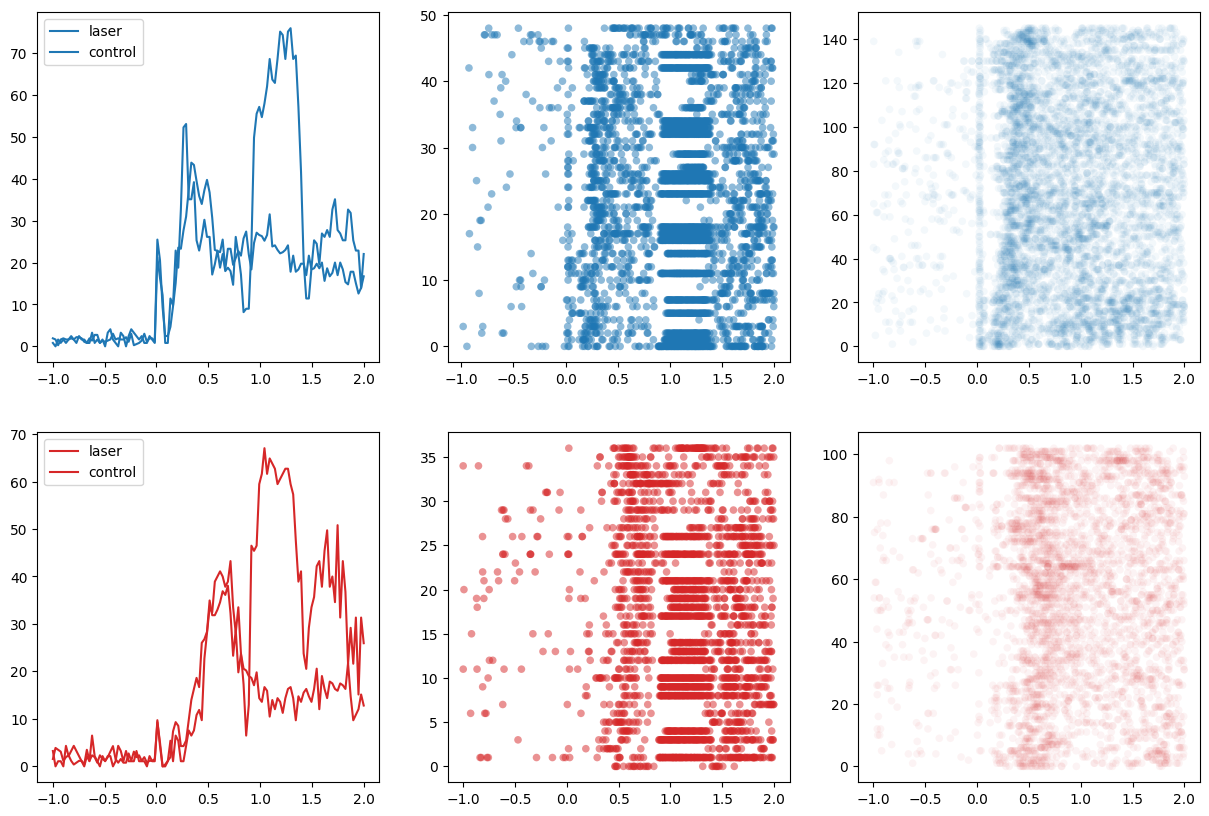

In [101]:
# Plot firing rate per neuron
# 73: high firing, 23, 67, 37: modulated
fig, ax = plt.subplots(2,3,figsize=(15,10))
unit_id = 114

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.5
alpha_laser  = 1.0

aligned = aligned_trial_start

# Row 0: left trials
plot_sem(aligned['reward_left_laser']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_laser, plot_individual=False, ax=ax[0,0], label='laser')
plot_sem(aligned['reward_left_control']['rate'][unit_id,:,:], x=xaxis, color=left_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[0,0], label='control')
ax[0,0].legend()
plot_raster(aligned['reward_left_laser']['times'][unit_id], x=xaxis, color=left_color, alpha=0.5*alpha_laser, ax=ax[0,1])
plot_raster(aligned['reward_left_control']['times'][unit_id], x=xaxis, color=left_color, alpha=0.1*alpha_ctrl, ax=ax[0,2])

# Row 1: right trials
plot_sem(aligned['reward_right_laser']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_laser, plot_individual=False, ax=ax[1,0], label='laser')
plot_sem(aligned['reward_right_control']['rate'][unit_id,:,:], x=xaxis, color=right_color, alpha=alpha_ctrl, plot_individual=False, ax=ax[1,0], label='control')
ax[1,0].legend()
plot_raster(aligned['reward_right_laser']['times'][unit_id], x=xaxis, color=right_color, alpha=0.5*alpha_laser, ax=ax[1,1])
plot_raster(aligned['reward_right_control']['times'][unit_id], x=xaxis, color=right_color, alpha=0.1*alpha_ctrl, ax=ax[1,2])


print('Laser modulation index: ' + str(laser_mod_index[unit_id]))
print('Tone modulation index: ' + str(tone_mod_index[unit_id]))
print('Choice modulation index: ' + str(choice_mod_index[unit_id]))
print('Reward modulation index: ' + str(reward_mod_index[unit_id]))


## 4. Plot trajectory aligned to events

In [102]:
# combine left and right data
criteria = None
aligned = aligned_last_lick

left_control_keys = ['reward_left_control', 'nonreward_left_control']
left_laser_keys = ['reward_left_laser', 'nonreward_left_laser']
right_control_keys = ['reward_right_control', 'nonreward_right_control']
right_laser_keys = ['reward_right_laser', 'nonreward_right_laser']

left_list_control = [aligned[k]['rate'] for k in left_control_keys]
left_rates_control = np.concatenate(left_list_control, axis=1)

right_list_control = [aligned[k]['rate'] for k in right_control_keys]
right_rates_control = np.concatenate(right_list_control, axis=1)

left_list_laser = [aligned[k]['rate'] for k in left_laser_keys]
left_rates_laser = np.concatenate(left_list_laser, axis=1)

right_list_laser = [aligned[k]['rate'] for k in right_laser_keys]
right_rates_laser = np.concatenate(right_list_laser, axis=1)

if criteria is not None:
    left_rates_control = left_rates_control[criteria, :, :]
    right_rates_control = right_rates_control[criteria, :, :]
    left_rates_laser = left_rates_laser[criteria, :, :]
    right_rates_laser = right_rates_laser[criteria, :, :]

left_color   = 'tab:blue'
right_color  = 'tab:red'
alpha_ctrl   = 0.3
alpha_laser  = 1.0

### 4.1. Plot projection onto CD_choice

In [81]:
def project(data, decoder=None, cd=None):
    """
    Projects data using the provided decoder or cd vector. If neither is provided, returns data unchanged.
    Only one of decoder or cd should be provided.

    Parameters:
    - data: np.ndarray, shape (n_neurons,) or (n_neurons, n_samples)
    - decoder: fitted classifier with coef_ and intercept_ attributes, or None
    - cd: np.ndarray, shape (n_neurons,), or None

    Returns:
    - projected data: np.ndarray
    """

    # data = remove_nan_trials(data)
    if isinstance(data, np.ndarray) and data.ndim == 3:
        data = np.nanmean(data, axis=1)

    if (decoder is not None) and (cd is not None):
        raise ValueError("Only one of 'decoder' or 'cd' should be provided.")
    if decoder is not None:
        w = decoder.coef_[0]       # shape (n_neurons,)
        b = decoder.intercept_[0]  # scalar
        return w.dot(data) + b
    elif cd is not None:
        return np.dot(cd, data)
    else:
        return data

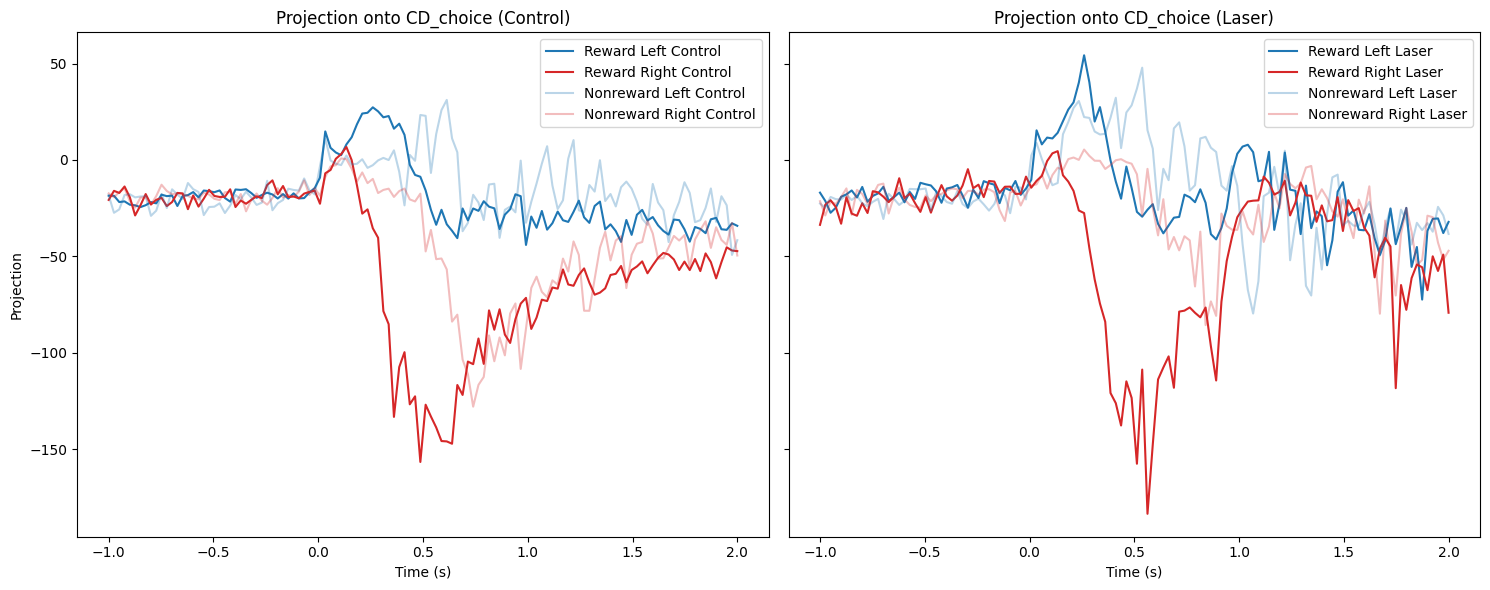

In [103]:
cd_choice = get_mod_index(left_rates, right_rates, type='cd')
aligned = aligned_trial_start

# Get projections for control
proj_reward_left_control = project(aligned['reward_left_control']['rate'], cd=cd_choice)
proj_reward_right_control = project(aligned['reward_right_control']['rate'], cd=cd_choice)
proj_nonreward_left_control = project(aligned['nonreward_left_control']['rate'], cd=cd_choice)
proj_nonreward_right_control = project(aligned['nonreward_right_control']['rate'], cd=cd_choice)

# Get projections for laser
proj_reward_left_laser = project(aligned['reward_left_laser']['rate'], cd=cd_choice)
proj_reward_right_laser = project(aligned['reward_right_laser']['rate'], cd=cd_choice)
proj_nonreward_left_laser = project(aligned['nonreward_left_laser']['rate'], cd=cd_choice)
proj_nonreward_right_laser = project(aligned['nonreward_right_laser']['rate'], cd=cd_choice)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
# Left: Control
axs[0].plot(xaxis, proj_reward_left_control, color=left_color, alpha=alpha_laser, label='Reward Left Control')
axs[0].plot(xaxis, proj_reward_right_control, color=right_color, alpha=alpha_laser, label='Reward Right Control')
axs[0].plot(xaxis, proj_nonreward_left_control, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Control')
axs[0].plot(xaxis, proj_nonreward_right_control, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Control')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Projection')
axs[0].set_title('Projection onto CD_choice (Control)')
axs[0].legend()

# Right: Laser
axs[1].plot(xaxis, proj_reward_left_laser, color=left_color, alpha=alpha_laser, label='Reward Left Laser')
axs[1].plot(xaxis, proj_reward_right_laser, color=right_color, alpha=alpha_laser, label='Reward Right Laser')
axs[1].plot(xaxis, proj_nonreward_left_laser, color=left_color, alpha=alpha_ctrl, label='Nonreward Left Laser')
axs[1].plot(xaxis, proj_nonreward_right_laser, color=right_color, alpha=alpha_ctrl, label='Nonreward Right Laser')
axs[1].set_xlabel('Time (s)')
axs[1].set_title('Projection onto CD_choice (Laser)')
axs[1].legend()

plt.tight_layout()
plt.show()


### 4.2. Plot PCA trajectory

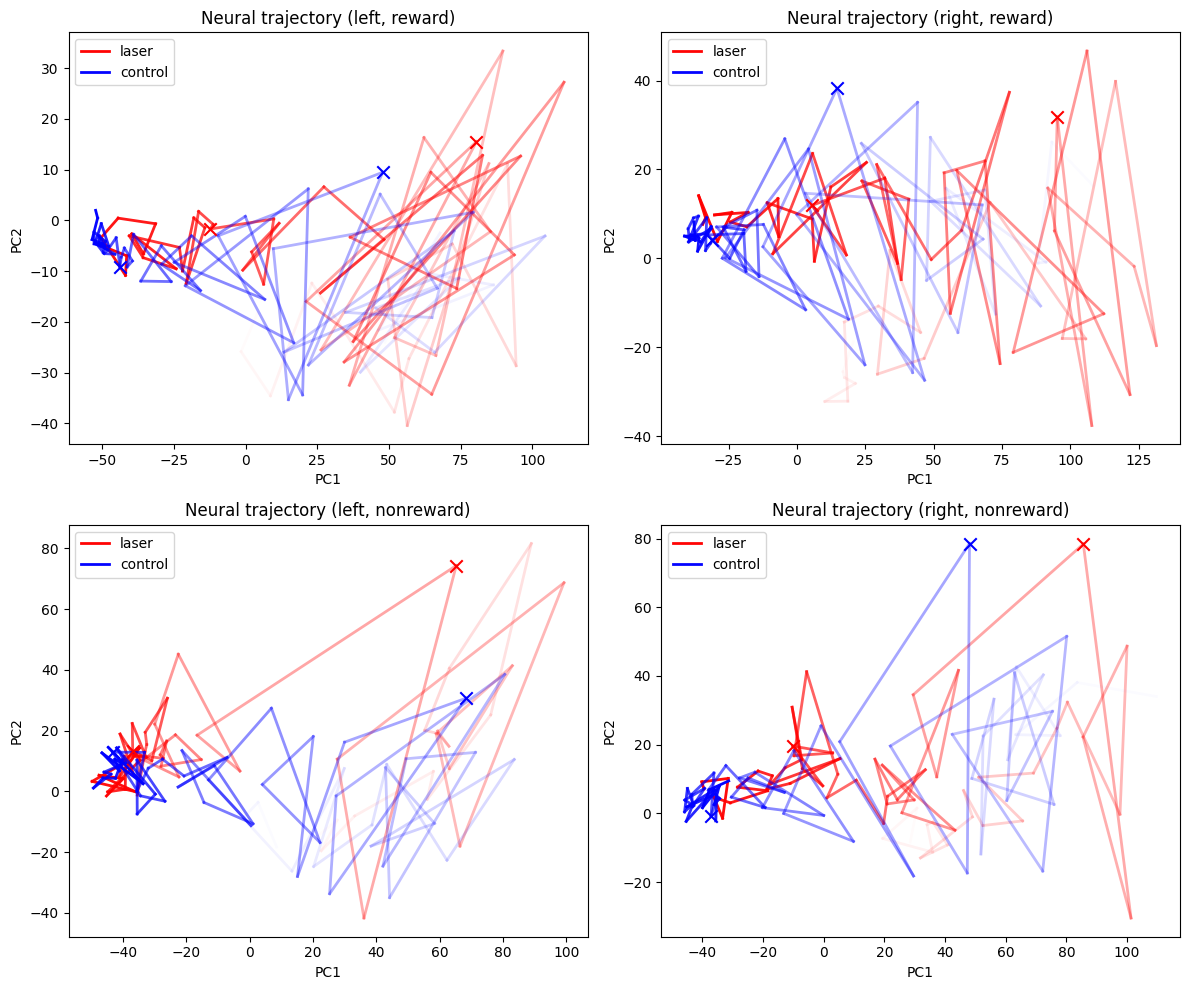

In [ ]:
from sklearn.decomposition import PCA

# ─── Generate PCA ───────────────────────────────────────
control_data = np.concatenate([left_rates_control, right_rates_control], axis=1)
control_data = np.nanmean(control_data, axis=1).T
pca_control = PCA(n_components=3).fit(control_data)

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
key_time = [0, 1]

# ─── Top‐Left: Left Trials Trajectory ───────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores, color='red', ax=axs[0,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores,  color='blue',  ax=axs[0,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,0].legend()
axs[0,0].set_xlabel('PC1')
axs[0,0].set_ylabel('PC2')
axs[0,0].set_title('Neural trajectory (left, reward)')

# ─── Top‐Right: Right Trials Trajectory ────────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['reward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores, color='red',   ax=axs[0,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['reward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['reward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores,  color='blue',  ax=axs[0,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[0,1].legend()
axs[0,1].set_xlabel('PC1')
axs[0,1].set_ylabel('PC2')
axs[0,1].set_title('Neural trajectory (right, reward)')

# ─── Bottom‐Left: left no reward trajectory ─────────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores, color='red',   ax=axs[1,0], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_left_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_left_control']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores,  color='blue',  ax=axs[1,0], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,0].legend()
axs[1,0].set_xlabel('PC1')
axs[1,0].set_ylabel('PC2')
axs[1,0].set_title('Neural trajectory (left, nonreward)')

# ─── Bottom‐Right: right no reward trajectory ───────────────────────────────
# Laser
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_laser']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores, color='red',   ax=axs[1,1], label='laser',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

# Control
if criteria is not None:
    data = np.nanmean(aligned['nonreward_right_control']['rate'][criteria, :, :], axis=1).T
else:
    data = np.nanmean(aligned['nonreward_right_control']['rate'], axis=1).T
scores = pca_control.transform(data)
plot_pca(scores,  color='blue',  ax=axs[1,1], label='control',
        key_time=key_time, time_range=time_range, bin_size_ms=bin_size)

axs[1,1].legend()
axs[1,1].set_xlabel('PC1')
axs[1,1].set_ylabel('PC2')
axs[1,1].set_title('Neural trajectory (right, nonreward)')

plt.tight_layout()
plt.show()


## 5. Find the coding direction

In [29]:
from pyNeuroDAP.spikes import get_decoders, project

### 1. Left and right axis

In [30]:
# Run to get decoder
window_size = 100   # in ms
decoders, accs = get_decoders(left_rates_control, right_rates_control, 
                                window_size_ms=window_size, bin_size_ms=bin_size, max_iter=10000)

Selected decoder accuracy: 0.9565217391304348


Text(0, 0.5, 'Projection (--> right)')

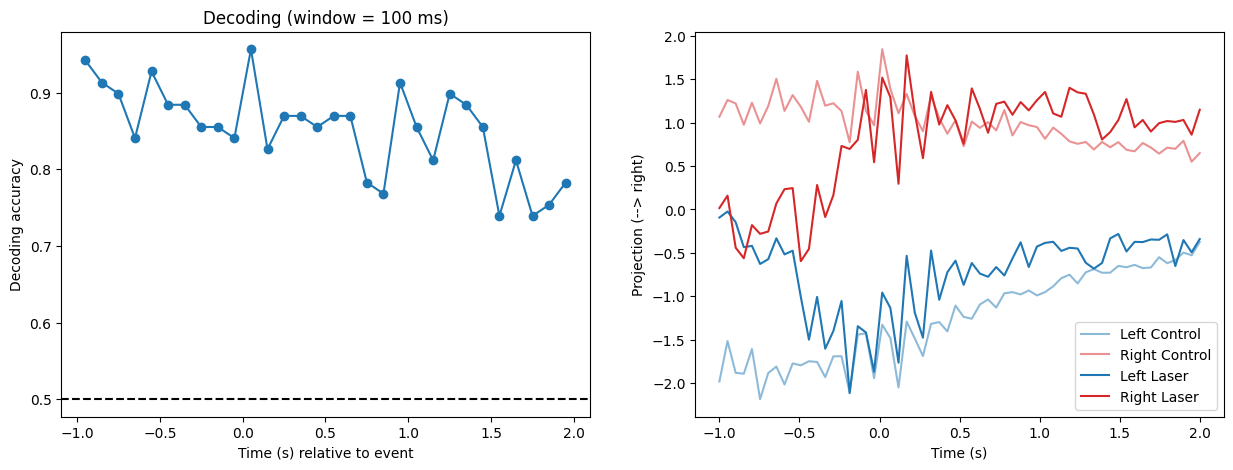

In [31]:
# Select decoder
# Note: -7 to -6, shape looks very different
index = np.argmax(accs)
print('Selected decoder accuracy: ' + str(accs[index]))
decoder_left_right = decoders[index]


fig, axs = plt.subplots(1,2, figsize=(15,5))
# plot accuracy vs. time (bin centers)
# compute time‐bin centers
n_bins = aligned['reward_left_laser']['params']['n_timestep']
window_size_in_bins = max(1, int(round(window_size / bin_size)))
n_windows    = int(np.ceil(n_bins / window_size_in_bins))
time_bins    = np.linspace(time_range[0], time_range[1], n_bins, endpoint=False) + bin_size/1000/2
time_centers = [
    time_bins[i*window_size_in_bins : min((i+1)*window_size_in_bins, n_bins)].mean()
    for i in range(n_windows)
]
# plot
axs[0].plot(time_centers, accs, '-o')
axs[0].axhline(0.5, color='k', linestyle='--')
axs[0].set_xlabel('Time (s) relative to event')
axs[0].set_ylabel('Decoding accuracy')
axs[0].set_title(f'Decoding (window = {window_size} ms)')

# Plot projection
xaxis = np.linspace(time_range[0], time_range[1], n_bins)

left_control_trial_avg = np.nanmean(left_rates_control,axis=1)
right_control_trial_avg = np.nanmean(right_rates_control,axis=1)
proj_left_control = project(left_control_trial_avg, decoder_left_right)
proj_right_control = project(right_control_trial_avg, decoder_left_right)

left_laser_trial_avg = np.nanmean(left_rates_laser,axis=1)
right_laser_trial_avg = np.nanmean(right_rates_laser,axis=1)
proj_left_laser = project(left_laser_trial_avg, decoder_left_right)
proj_right_laser = project(right_laser_trial_avg, decoder_left_right)

axs[1].plot(xaxis, proj_left_control,  color=left_color,  alpha=alpha_ctrl,  label='Left Control')
axs[1].plot(xaxis, proj_right_control, color=right_color, alpha=alpha_ctrl,  label='Right Control')
axs[1].plot(xaxis, proj_left_laser,    color=left_color,  alpha=alpha_laser, label='Left Laser')
axs[1].plot(xaxis, proj_right_laser,   color=right_color, alpha=alpha_laser, label='Right Laser')

axs[1].legend()
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Projection (--> right)')

Text(0.5, 1.0, 'Spearman ρ = -0.059, p = 0.488')

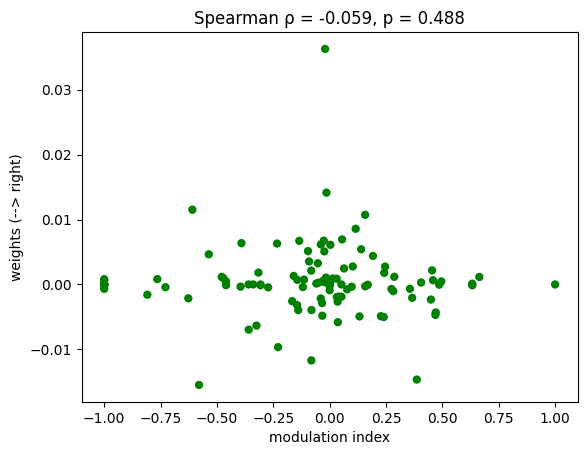

In [ ]:
# Correlation of the decoder weights and laser_mod_index
w_units = decoder_left_right.coef_[0]
if criteria is not None: 
    mod_index_included = laser_mod_index[criteria]
else: 
    mod_index_included = laser_mod_index

from scipy.stats import spearmanr
r_spear, p_spear = spearmanr(mod_index_included, w_units)

plt.scatter(mod_index_included, w_units, color='green', edgecolor='None')
plt.xlabel('modulation index')
plt.ylabel('weights (--> right)')
plt.title(f"Spearman ρ = {r_spear:.3f}, p = {p_spear:.3g}")